In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# Fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Data as pandas DataFrames
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Display first 5 feature records
print("Features:")
print(X.head())

# Display first 5 target records
print("\nTarget:")
print(y.head())

# Metadata
print("\nMetadata:")
print(breast_cancer_wisconsin_diagnostic.metadata)

# Variable information
print("\nVariables:")
print(breast_cancer_wisconsin_diagnostic.variables)

Features:
   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \
0     17.33   

In [4]:
# Summary statistics for all features
print(X.describe())

          radius1    texture1  perimeter1        area1  smoothness1  \
count  569.000000  569.000000  569.000000   569.000000   569.000000   
mean    14.127292   19.289649   91.969033   654.889104     0.096360   
std      3.524049    4.301036   24.298981   351.914129     0.014064   
min      6.981000    9.710000   43.790000   143.500000     0.052630   
25%     11.700000   16.170000   75.170000   420.300000     0.086370   
50%     13.370000   18.840000   86.240000   551.100000     0.095870   
75%     15.780000   21.800000  104.100000   782.700000     0.105300   
max     28.110000   39.280000  188.500000  2501.000000     0.163400   

       compactness1  concavity1  concave_points1   symmetry1  \
count    569.000000  569.000000       569.000000  569.000000   
mean       0.104341    0.088799         0.048919    0.181162   
std        0.052813    0.079720         0.038803    0.027414   
min        0.019380    0.000000         0.000000    0.106000   
25%        0.064920    0.029560         

In [5]:
print("Mean:")
print(X.mean())

print("\nMedian:")
print(X.median())

print("\nStandard Deviation:")
print(X.std())

Mean:
radius1                14.127292
texture1               19.289649
perimeter1             91.969033
area1                 654.889104
smoothness1             0.096360
compactness1            0.104341
concavity1              0.088799
concave_points1         0.048919
symmetry1               0.181162
fractal_dimension1      0.062798
radius2                 0.405172
texture2                1.216853
perimeter2              2.866059
area2                  40.337079
smoothness2             0.007041
compactness2            0.025478
concavity2              0.031894
concave_points2         0.011796
symmetry2               0.020542
fractal_dimension2      0.003795
radius3                16.269190
texture3               25.677223
perimeter3            107.261213
area3                 880.583128
smoothness3             0.132369
compactness3            0.254265
concavity3              0.272188
concave_points3         0.114606
symmetry3               0.290076
fractal_dimension3      0.083946
dtyp

In [6]:
# Check missing values in each feature
print("Missing values:")
print(X.isnull().sum())

Missing values:
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64


In [7]:
# Check duplicate rows
print("Number of duplicate rows:", X.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Check potential outliers using IQR
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

outliers = ((X < (Q1 - 1.5 * IQR)) |
            (X > (Q3 + 1.5 * IQR)))

print("Potential outliers in each feature:")
print(outliers.sum())

Potential outliers in each feature:
radius1               14
texture1               7
perimeter1            13
area1                 25
smoothness1            6
compactness1          16
concavity1            18
concave_points1       10
symmetry1             15
fractal_dimension1    15
radius2               38
texture2              20
perimeter2            38
area2                 65
smoothness2           30
compactness2          28
concavity2            22
concave_points2       19
symmetry2             27
fractal_dimension2    28
radius3               17
texture3               5
perimeter3            15
area3                 35
smoothness3            7
compactness3          16
concavity3            12
concave_points3        0
symmetry3             23
fractal_dimension3    24
dtype: int64


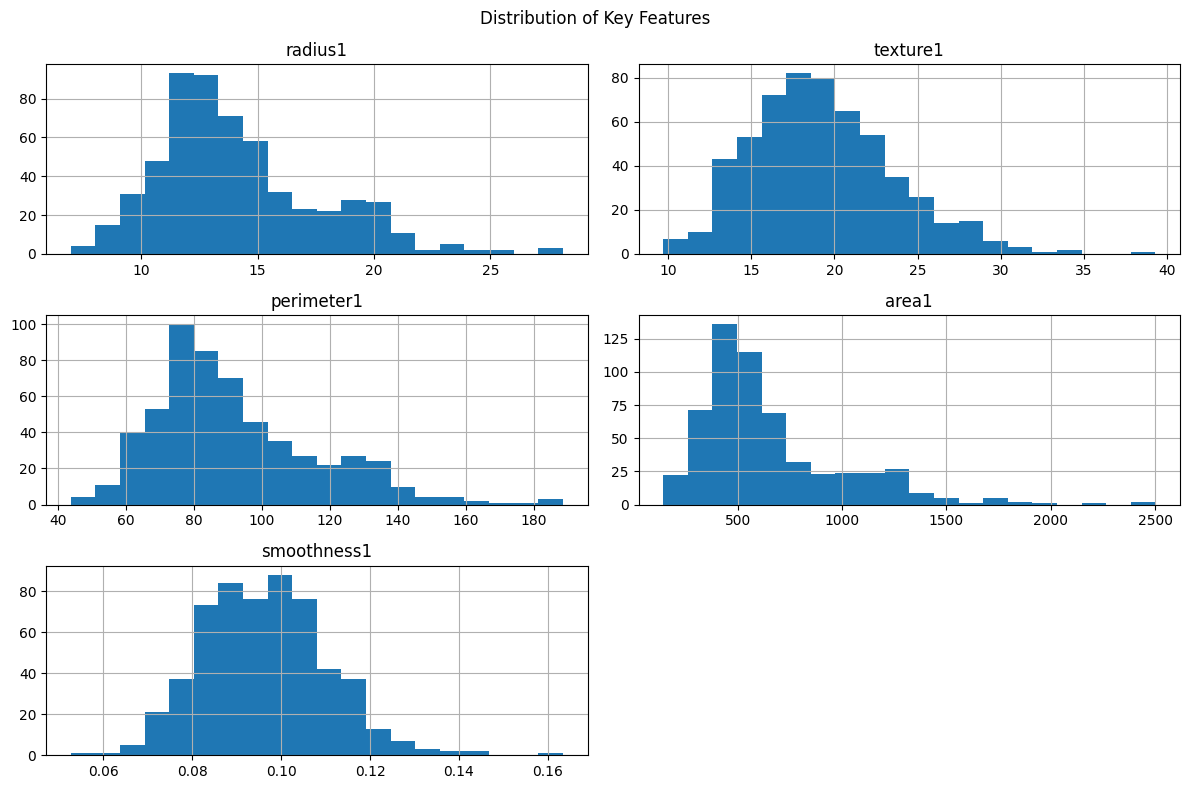

In [9]:
import matplotlib.pyplot as plt

# Select key features
key_features = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1']

# Create histograms
X[key_features].hist(figsize=(12, 8), bins=20)

plt.suptitle("Distribution of Key Features")
plt.tight_layout()
plt.show()

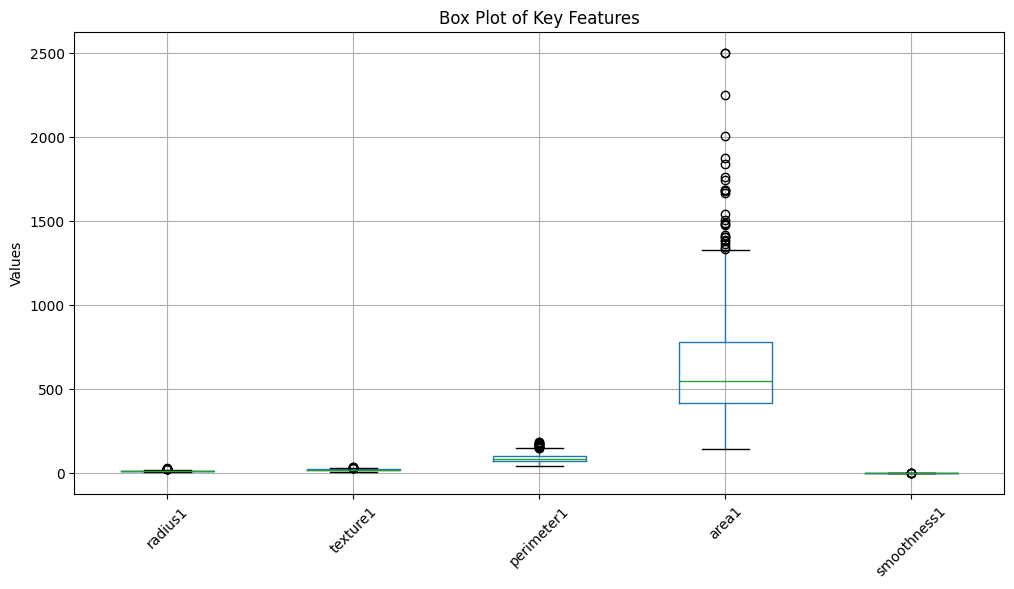

In [10]:
plt.figure(figsize=(12, 6))

X[key_features].boxplot()

plt.title("Box Plot of Key Features")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.show()

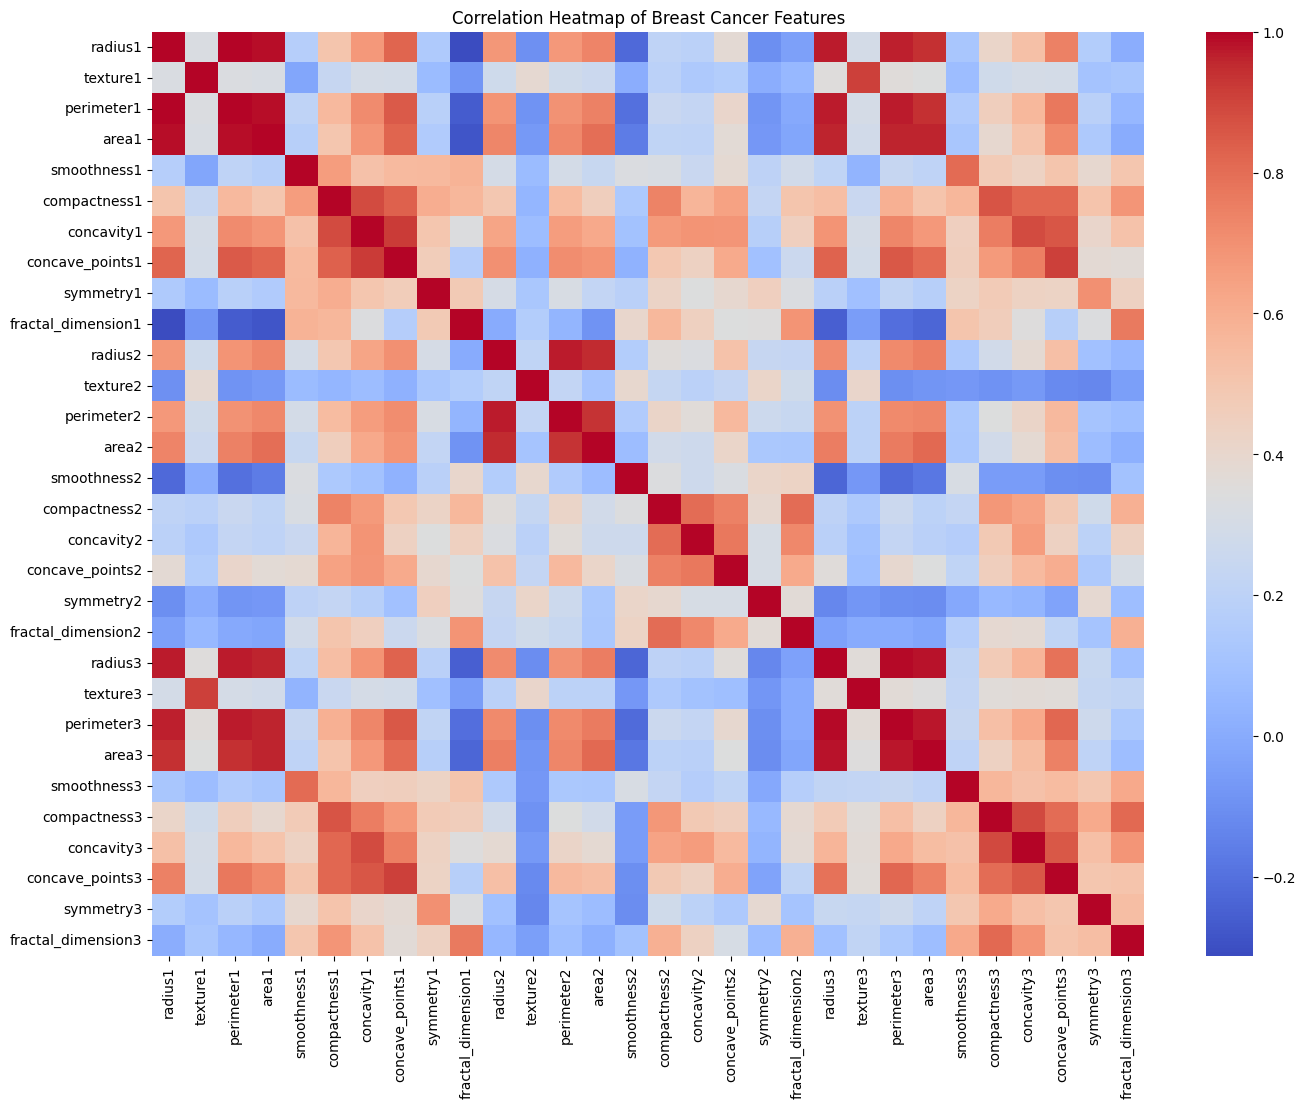

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
correlation_matrix = X.corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Breast Cancer Features")
plt.show()

Class distribution:
Diagnosis
B    357
M    212
Name: count, dtype: int64


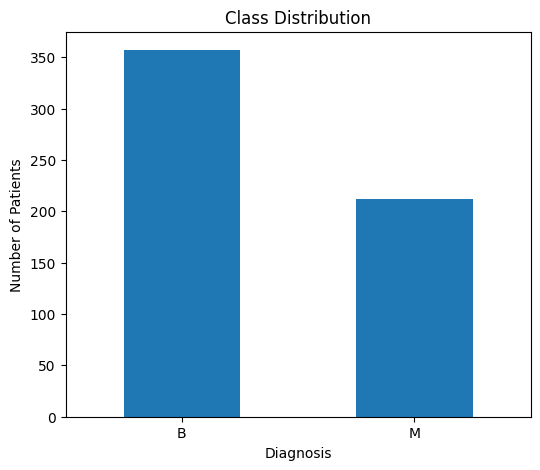

In [12]:
import matplotlib.pyplot as plt

# Count each class
print("Class distribution:")
print(y['Diagnosis'].value_counts())

# Visualize class distribution
y['Diagnosis'].value_counts().plot(
    kind='bar',
    figsize=(6, 5)
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1. Encode target variable as binary
# M = 1 (Malignant)
# B = 0 (Benign)
# --------------------------------------------------

y_binary = y['Diagnosis'].map({'M': 1, 'B': 0})

print("Encoded target:")
print(y_binary.head())

print("\nClass distribution after encoding:")
print(y_binary.value_counts())


# --------------------------------------------------
# 2. Split data into training and testing sets
#    80% training, 20% testing
#    Stratified sampling maintains class proportion
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


# --------------------------------------------------
# 3. Standardize the features
# --------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled training data:")
print(X_train_scaled[:5])

print("\nScaled testing data:")
print(X_test_scaled[:5])

Encoded target:
0    1
1    1
2    1
3    1
4    1
Name: Diagnosis, dtype: int64

Class distribution after encoding:
Diagnosis
0    357
1    212
Name: count, dtype: int64

Training set shape: (455, 30)
Testing set shape: (114, 30)

Training class distribution:
Diagnosis
0    285
1    170
Name: count, dtype: int64

Testing class distribution:
Diagnosis
0    72
1    42
Name: count, dtype: int64

Scaled training data:
[[ 5.18558727e-01  8.91825791e-01  4.24631702e-01  3.83925436e-01
  -9.74743706e-01 -6.89771505e-01 -6.88586446e-01 -3.98175254e-01
  -1.03915470e+00 -8.25056321e-01 -1.09317755e-01 -5.59755400e-02
  -2.10096206e-01 -1.59132582e-02 -1.00518399e+00 -9.11941990e-01
  -6.62815884e-01 -6.52561081e-01 -7.01889114e-01 -2.75393571e-01
   5.79797697e-01  1.31324246e+00  4.66908134e-01  4.45982711e-01
  -5.96154777e-01 -6.34722227e-01 -6.10227299e-01 -2.35743918e-01
   5.45663235e-02  2.18367276e-02]
 [-5.16364088e-01 -1.63971029e+00 -5.41348716e-01 -5.42961327e-01
   4.76219058e-01 

Accuracy: 0.9649122807017544

Precision: 0.975
Recall: 0.9285714285714286
F1-score: 0.9512195121951219

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Confusion Matrix:
[[71  1]
 [ 3 39]]


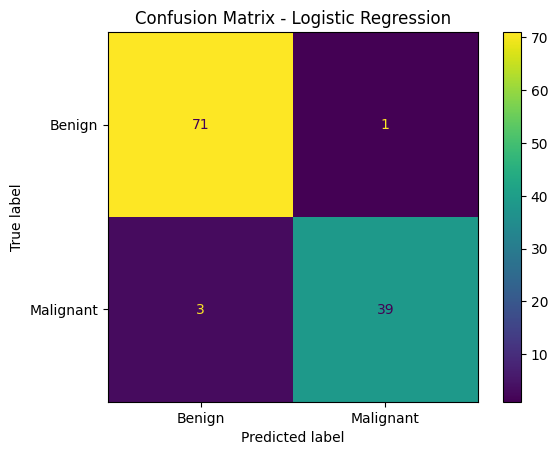


AUC Score: 0.996031746031746


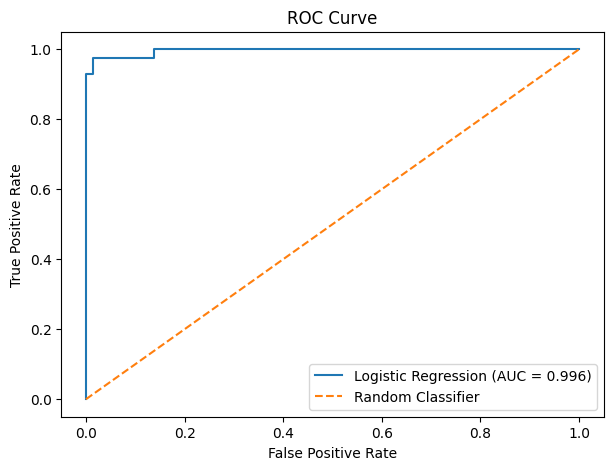

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Train Logistic Regression Model
# --------------------------------------------------

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)


# --------------------------------------------------
# 2. Make Predictions
# --------------------------------------------------

y_pred = model.predict(X_test_scaled)

# Probability of malignant class (1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


# --------------------------------------------------
# 3. Accuracy
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


# --------------------------------------------------
# 4. Precision, Recall and F1-score
# --------------------------------------------------

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


# --------------------------------------------------
# 5. Classification Report for Both Classes
# --------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)


# --------------------------------------------------
# 6. Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# --------------------------------------------------
# 7. ROC Curve and AUC
# --------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("\nAUC Score:", auc_score)


# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()